# Домашнее задание 1
**Датасет: Used car prices**

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
target_col = 'price'

In [4]:
df = pd.read_csv("used_cars.csv")
df.shape


(4009, 12)

In [5]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


**Сначала проведу разведочный анализ данных, чтобы была основа для формирования гипотез**

In [ ]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


Заметим, что столбец milage имеет тип данных str только потому что там стоит mi

Проверим нет ли там чего-то кроме mi, например km, и убирём текст, приведём к int

In [25]:
suffixes = df['milage'].str.extract(r'[\d,]+\s*([a-zA-Z.]+)')
print(suffixes[0].unique())

<ArrowStringArray>
['mi.']
Length: 1, dtype: str


In [29]:
df['milage'] = df['milage'].str.extract(r'([\d,]+)')[0].str.replace(',', '').astype(int)

AttributeError: Can only use .str accessor with string values, not integer

In [35]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Та же проблема со столбцом price из-за знака доллара в начале. Проверим все ли цены в 

долларах и приведём данный столбец к инту

In [36]:
prefixes = df['price'].str.extract(r'^([^0-9]*)')[0]
print(prefixes.unique())

<ArrowStringArray>
['$']
Length: 1, dtype: str


In [37]:
df['price'] = df['price'].str.extract(r'([\d,]+)')[0].str.replace(',', '').astype(int)

In [38]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999


Всё теперь с этими столбцами всё в порядке

In [8]:
nan_counts = df.isna().sum()
print(nan_counts)

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


Теперь посмотрим на распределение таргета, чтобы понять нужно ли применять какую-либо трансформацию к нему

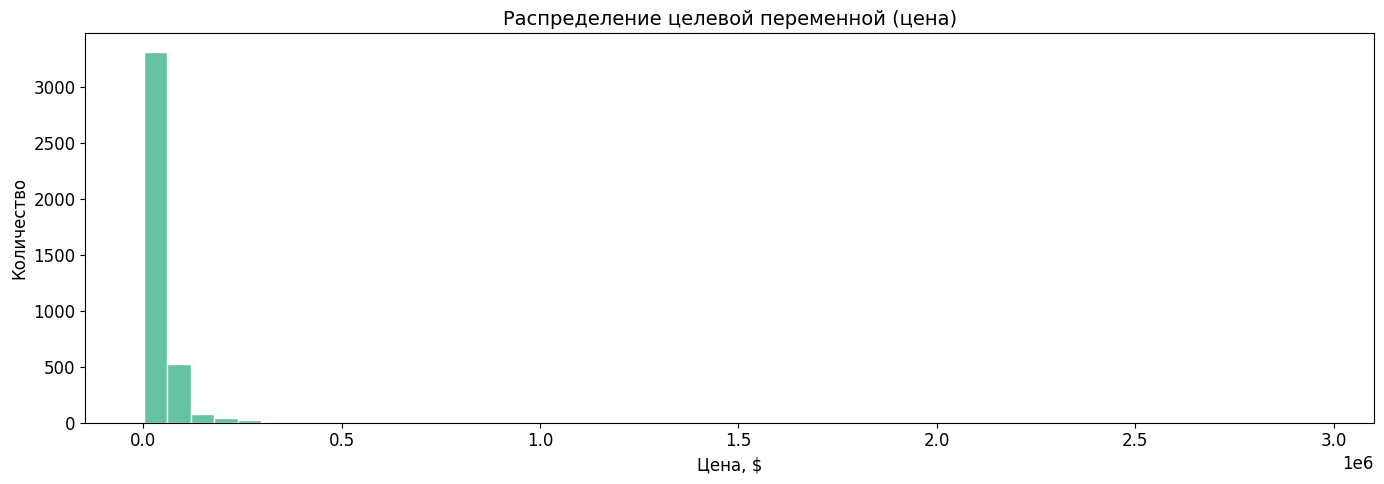

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(df['price'], bins=50, color=sns.color_palette('Set2')[0], edgecolor='white')
ax.set_title('Распределение целевой переменной (цена)', fontsize=14)
ax.set_xlabel('Цена, $')
ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

Видно что машины сгрудились около цен порядка 100-200 тысяч, но при этом вся ось растянута аж до 3 миллионов, значит, что в основном в выборке машины за 100-200 тысяч, но при этом есть и гиперкары с высокой стоимостью, т.е. они являются выбросами. Тут и рождается моя гипотеза №1

**Гипотеза №1**: Если прологарифмировать таргет, то модель станет предсказывать цену лучше.

Краткое поясниние: Как было сказано на первом семинаре если у нас есть большие выбросы в таргете но при этом они не единичны и значимы (как раз этот случай), чтобы MSE не завышалось (так как модели очень больно ошибаться на дорогих она будет лучше подстраиваться под них жертвуя качеством предсказания на основной массе). Поэтому мы сожмём разброс таргета за счёт логарифма.

**Важно:** Я не знаю как органично расположить саму гипотезу и её проверку не разрывая при этом EDA, поэтому проверять я буду именно после EDA.

А сейчас посмотрим на выбросы

In [ ]:
print(df.nlargest(5, 'price')[['brand', 'model', 'price']])

            brand                    model    price
693      Maserati        Quattroporte Base  2954083
229       Bugatti  Veyron 16.4 Grand Sport  1950995
3046      Porsche          Carrera GT Base  1599000
1356  Lamborghini       Aventador SVJ Base   749950
624   Rolls-Royce                 Cullinan   695000


Теперь построим диаграмму для распределения по признакам

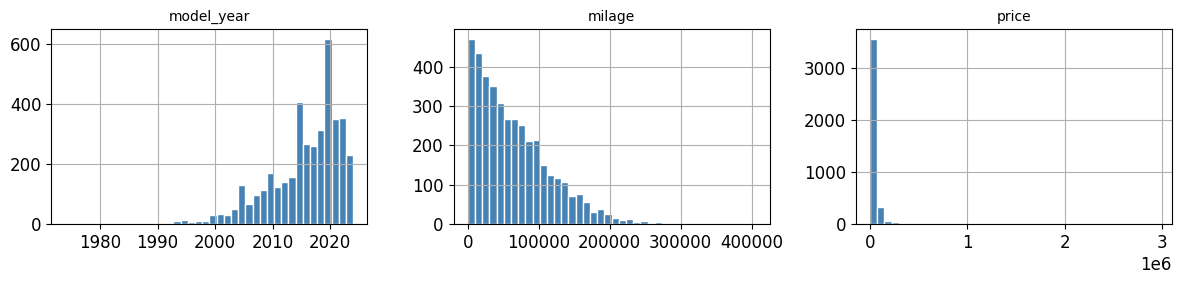

In [44]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Корреляционная матрица. Здесь некоторые категориальные (синтетические) добавим, стобы она была выразительнее

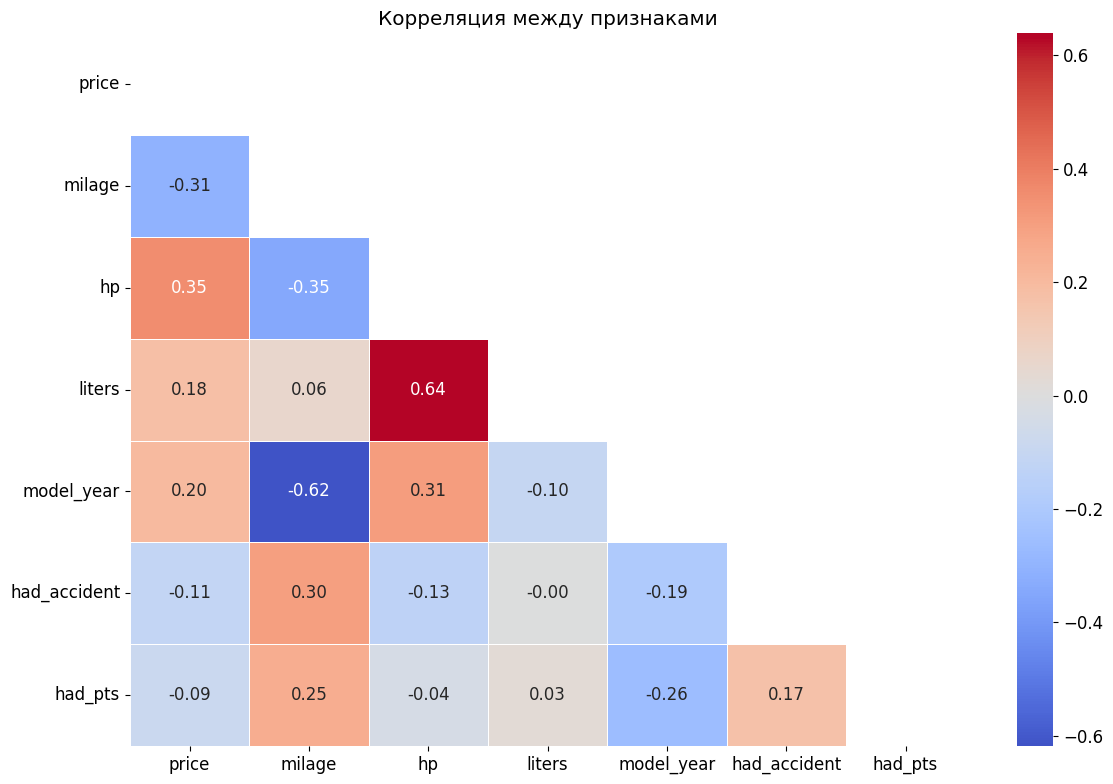

In [63]:
df_corr = df.copy()
df_corr['had_accident'] = (df['accident'] == 'At least 1 accident or damage reported').astype(int)
df_corr['had_pts'] = df['clean_title'].fillna('No').apply(lambda x: 1 if x == 'Yes' else 0)
df_corr['hp'] = df['engine'].str.extract(r'([\d.]+)HP').astype(float)
df_corr['liters'] = df['engine'].str.extract(r'([\d.]+)L').astype(float)

num_cols = ['price', 'milage', 'hp', 'liters', 'model_year', 'had_accident', 'had_pts']

plt.figure(figsize=(12, 8))
corr = df_corr[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()



В целом тут понятно что л.с. и объём двигателя скоррелированы (в самой таблице л.с. написаны не у всех машин, и если записаны то в том же столбце что и объём), а также сильно скоррелированы год выпуска и пробег, ну это тоже очевидно

Отсюда видим, что наибольшее влияние на цену оказывает именно мощность двигателя

Но меня смущает что корреляции везде такие маленькие. По логике, например, у признка "пробег" или "наличие аварий" (но вот именно у признака "наличие аварий" сложно проверить нелинеёность связи для этого scatter plot не подойдёт так как тут всего два значения 0 или 1) c ценой должна быть корреляция выше, поэтому я предполагаю, что проблема здесь кроется в корреляции Пирсона, которая не ловит нелинейные зависимости, отсюда рождается вторая гипотеза.

Что ещё странно слабая скоррелированность цены с годом выпуска автомобиля слабая (возможно из-за винтажных автомобилей), но в данном случае лучше сравнивать ещё с корреляцией Спирмена, потому что тут очевидно она больше линейная и логарифмировать бесполезно

Но до формулирования второй гипотезы как раз посмотрим на графике по каким конкретно признакам может связь с таргетом может быть нелинейной, для этого построим scatter plot

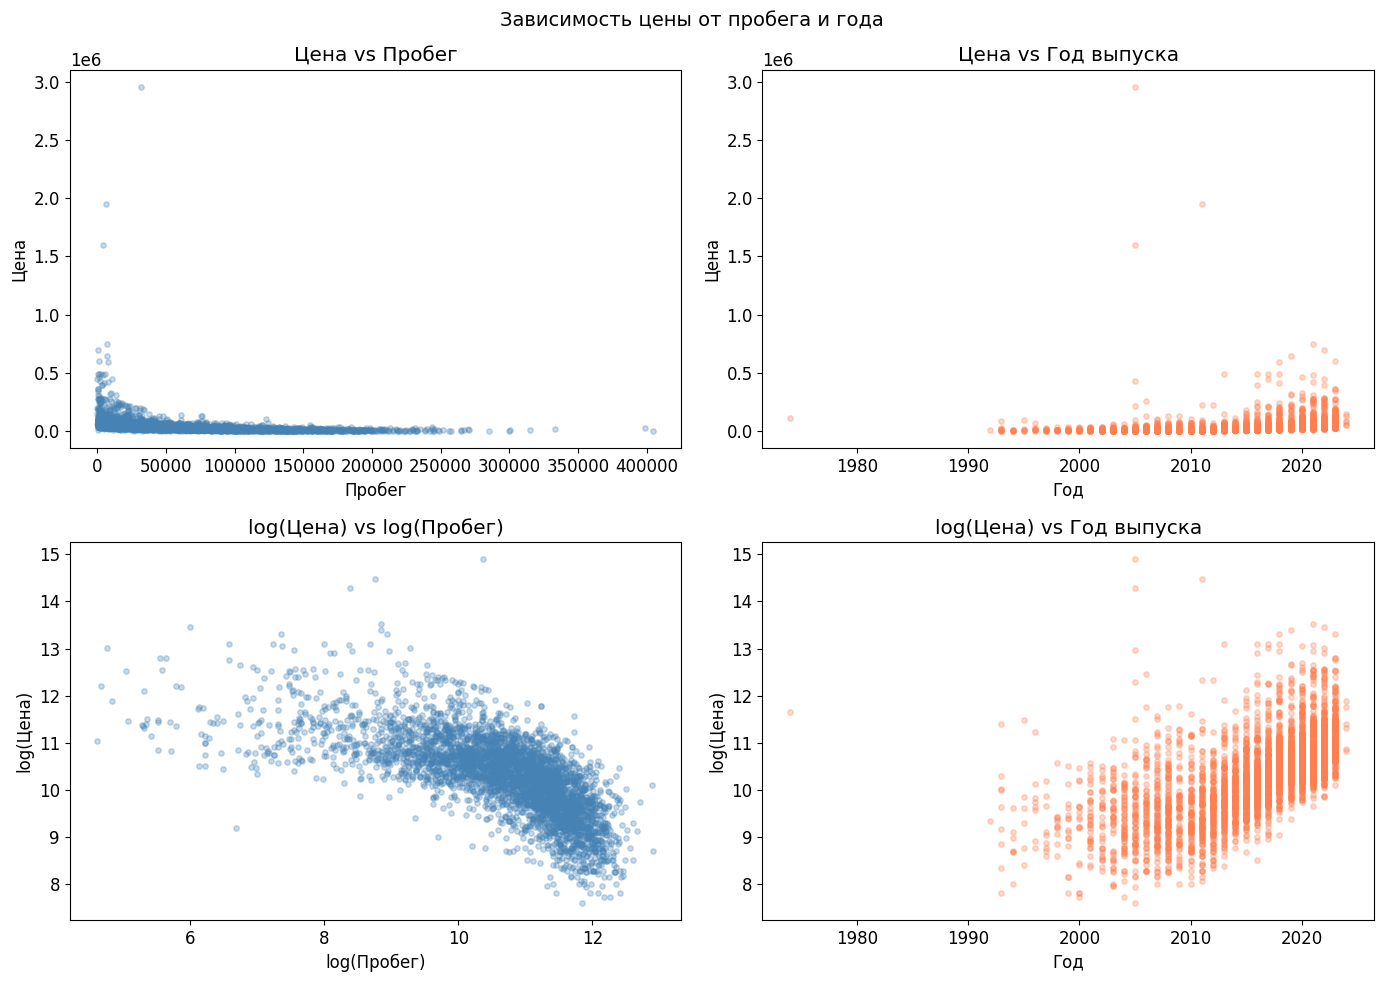

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(df['milage'], df['price'], alpha=0.3, s=15, color='steelblue')
axes[0][0].set_title('Цена vs Пробег')
axes[0][0].set_xlabel('Пробег')
axes[0][0].set_ylabel('Цена')

axes[0][1].scatter(df['model_year'], df['price'], alpha=0.3, s=15, color='coral')
axes[0][1].set_title('Цена vs Год выпуска')
axes[0][1].set_xlabel('Год')
axes[0][1].set_ylabel('Цена')

axes[1][0].scatter(np.log1p(df['milage']), np.log1p(df['price']), alpha=0.3, s=15, color='steelblue')
axes[1][0].set_title('log(Цена) vs log(Пробег)')
axes[1][0].set_xlabel('log(Пробег)')
axes[1][0].set_ylabel('log(Цена)')

axes[1][1].scatter(df['model_year'], np.log1p(df['price']), alpha=0.3, s=15, color='coral')
axes[1][1].set_title('log(Цена) vs Год выпуска')
axes[1][1].set_xlabel('Год')
axes[1][1].set_ylabel('log(Цена)')

plt.suptitle('Зависимость цены от пробега и года', fontsize=14)
plt.tight_layout()
plt.show()


Сначала у пробега было экспоненциальное падение, потом после логарифмирования признака появилась уже более линейная структура

**Гипотеза №2:** Метрику R^2 для линейной регрессии можно улучшить за счет логарифмирования признака milage

In [67]:
from scipy import stats

print("Пирсон:", df['price'].corr(df['model_year']))
print("Спирмен:", df['price'].corr(df['model_year'], method='spearman'))

Пирсон: 0.19949617383427903
Спирмен: 0.697388378365128


**Действительно связь нелинейна (корреляция Спирмена сильно выше корреляции Пирсона)**

Теперь посмотрими на влияние аварий на цену автомобиля

In [69]:
from scipy import stats

df_acc = df[df['accident'].notna()].copy()
df_acc['had_accident'] = (df_acc['accident'] == 'At least 1 accident or damage reported').astype(int)

corr, pvalue = stats.pointbiserialr(df_acc['had_accident'], df_acc['price'])
print(f"Корреляция: {corr:.3f}")
print(f"P-value: {pvalue:.4f}")

print(df_acc.groupby('had_accident')['price'].median())

Корреляция: -0.114
P-value: 0.0000
had_accident
0    35667.5
1    20900.0
Name: price, dtype: float64


Видно что Пирсон по итогу и здесь врёт (так как p-value = 0.0000 после округления, связь сильная), а это значит что связь здесь также нелинейна и это важный признак

**Гипотеза №3:** Несколько признаков в нашем датасете имеют нелинейную зависимость с таргетом, поэтому дерево решений даст лучший результат по метрике R^2 нежели чем линейная регрессия

**Гипотеза №4:** Наличие аварии влияет на цену автомобиля с разной силой в зависимости от ценового сегмента автомобиля (если машина высокого класса то влияние колоссально), поэтому добавление признака price_segment * had_accident (где price_segment = 1, если машина премиум-класса, иначе 0) улучшит значение метрики RMSE для модеили линейной регрессии 

Теперь построим boxplot цены по топ 10 (по частоте) маркам автомобилей

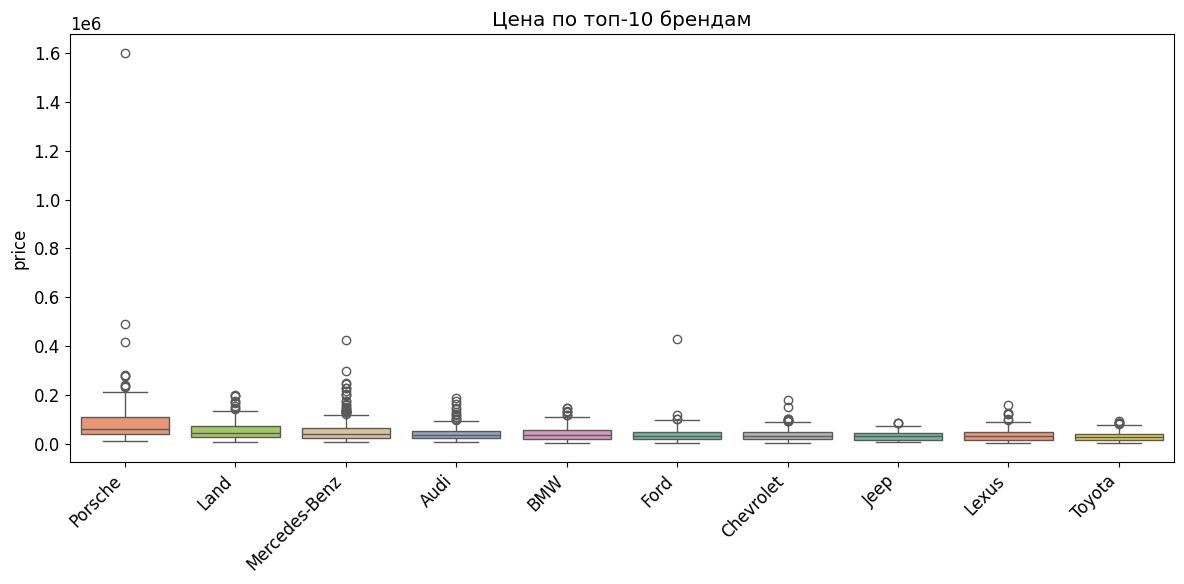

In [74]:
top10 = df['brand'].value_counts().head(10).index
df_top10 = df[df['brand'].isin(top10)]

order = df_top10.groupby('brand')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10, x='brand', y='price',
            order=order, hue='brand', legend=False, palette='Set2')
plt.title('Цена по топ-10 брендам')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Здесь подумал что гипотеза по силе признака бренда слишком тривиальна, но график решил не убирать

Pairplot

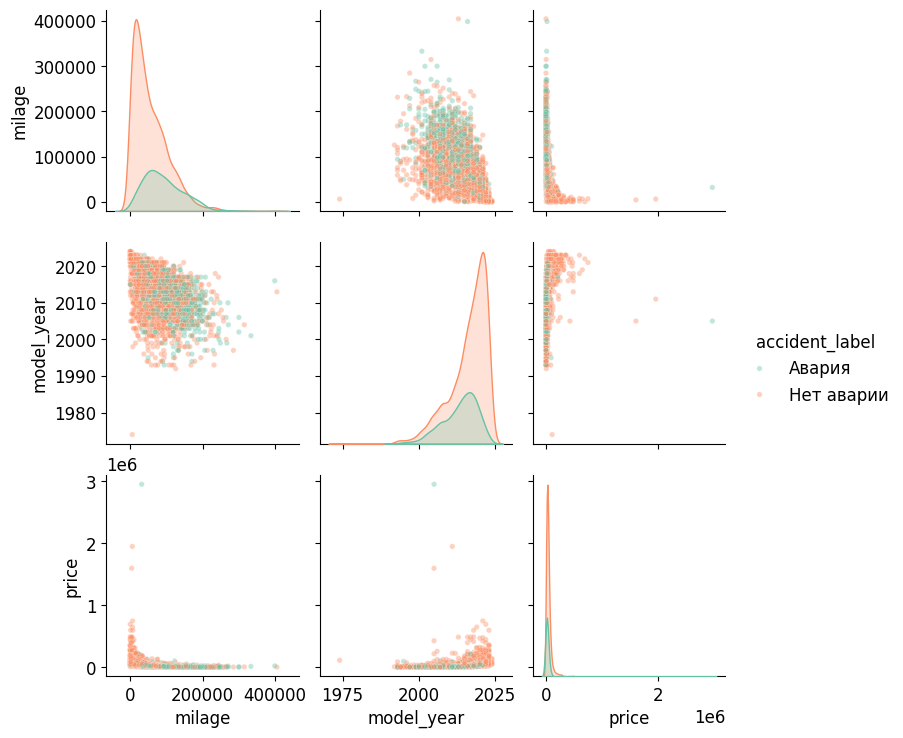

In [78]:
df['had_accident'] = (df['accident'] == 'At least 1 accident or damage reported')
df['accident_label'] = df['had_accident'].map({True: 'Авария', False: 'Нет аварии'})

sns.pairplot(df[['milage', 'model_year', 'accident_label', target_col]].dropna(),
             hue='accident_label', palette='Set2',
             plot_kws={'alpha': 0.4, 's': 15})
plt.show()

# Итоги EDA:
Разведочный анализ данных закончен на его основе были сформулированы три гипотезы:

**Гипотеза №1**: Если прологарифмировать таргет, то предсказание модели станет точенее по метрикам R² и RMSE.

**Гипотеза №2:** Метрику R² для линейной регрессии можно улучшить за счет логарифмирования признака milage

**Гипотеза №3:** Несколько признаков в нашем датасете имеют нелинейную зависимость с таргетом, поэтому дерево решений даст лучший результат по метрикам R² и RMSE, нежели чем линейная регрессия

**Гипотеза №4:** Наличие аварии влияет на цену автомобиля с разной силой в зависимости от ценового сегмента автомобиля (если машина высокого класса то влияние колоссально), поэтому добавление признака price_segment * had_accident (где price_segment = 1, если машина премиум-класса, иначе 0) улучшит значение метрик R² и RMSE для модели линейной регрессии

# Подготовка данных

In [81]:
from sklearn.model_selection import train_test_split

df['had_accident'] = (df['accident'] == 'At least 1 accident or damage reported').astype(int)
df['is_automatic'] = df['transmission'].apply(lambda x: 0 if 'M/T' in str(x) or 'Manual' in str(x) else 1)
df['hp'] = df['engine'].str.extract(r'([\d.]+)HP').astype(float)
df['liters'] = df['engine'].str.extract(r'([\d.]+)L').astype(float)
df['is_clean_title'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)
df['fuel_type'] = df['fuel_type'].replace({'not supported': np.nan, '–': np.nan})

features = ['milage', 'model_year', 'hp', 'liters', 'had_accident', 'is_automatic', 'is_clean_title','brand', 'model', 'fuel_type', 'ext_col', 'int_col']

X = df[features].copy()
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for col in ['milage', 'hp', 'liters']:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

for col in ['brand', 'model', 'ext_col', 'int_col']:
    col_map = y_train.groupby(X_train[col]).median()
    X_train[f'{col}_encoded'] = X_train[col].map(col_map)
    X_test[f'{col}_encoded'] = X_test[col].map(col_map).fillna(y_train.median())

fuel_mode = X_train['fuel_type'].mode()[0]
X_train['fuel_type'] = X_train['fuel_type'].fillna(fuel_mode)
X_test['fuel_type'] = X_test['fuel_type'].fillna(fuel_mode)

fuel_train = pd.get_dummies(X_train['fuel_type'], prefix='fuel', drop_first=True)
fuel_test = pd.get_dummies(X_test['fuel_type'], prefix='fuel', drop_first=True)
fuel_test = fuel_test.reindex(columns=fuel_train.columns, fill_value=0)

X_train = pd.concat([X_train, fuel_train], axis=1)
X_test = pd.concat([X_test, fuel_test], axis=1)

X_train = X_train.drop(columns=['brand', 'model', 'fuel_type', 'ext_col', 'int_col'])
X_test = X_test.drop(columns=['brand', 'model', 'fuel_type', 'ext_col', 'int_col'])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Колонки:", X_train.columns.tolist())

Train shape: (3207, 15)
Test shape: (802, 15)
Колонки: ['milage', 'model_year', 'hp', 'liters', 'had_accident', 'is_automatic', 'is_clean_title', 'brand_encoded', 'model_encoded', 'ext_col_encoded', 'int_col_encoded', 'fuel_E85 Flex Fuel', 'fuel_Gasoline', 'fuel_Hybrid', 'fuel_Plug-In Hybrid']


In [82]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())
print(X_train.dtypes)

milage                 0
model_year             0
hp                     0
liters                 0
had_accident           0
is_automatic           0
is_clean_title         0
brand_encoded          0
model_encoded          0
ext_col_encoded        0
int_col_encoded        0
fuel_E85 Flex Fuel     0
fuel_Gasoline          0
fuel_Hybrid            0
fuel_Plug-In Hybrid    0
dtype: int64
milage                 0
model_year             0
hp                     0
liters                 0
had_accident           0
is_automatic           0
is_clean_title         0
brand_encoded          0
model_encoded          0
ext_col_encoded        0
int_col_encoded        0
fuel_E85 Flex Fuel     0
fuel_Gasoline          0
fuel_Hybrid            0
fuel_Plug-In Hybrid    0
dtype: int64
milage                   int64
model_year               int64
hp                     float64
liters                 float64
had_accident             int64
is_automatic             int64
is_clean_title           int64
brand_e

Данные готовы к обработке, кодирование категориальных признаков выполнено. В данном случае столбцы: с авариями, о наличии документа, о типе трансмиссии, - я кодировал просто 0-нет аварии, документа и если трансмиссия не автомат, иначе по каждому признаку 1. Для бренда, модели, цветов интерьера и экстерьера я выбрал таргет кодирование, потому что в данном случае оно самое подходящие (one-hot и label дали бы слишком много столбцов), а для fuel_type я выбрал one_hot_encoding, так как там ограниченное количество типов. Столбец с данными о двигателе я поделил на hp - лошадиные силы и liters - объём двигателя, так как это основные характеристики и их можно привести к числовым типам, чтобы удобнее было делать по ним регрессию

Теперь после того как все признаки закодированы и теперь с ними можно производить вычисления я проведу отбор признаков, а именно я решил сделать RFE, хоть алгоритм и рекурсивный, но в нашем случае признаков мало и RFE не займёт много времени, поэтому сделаю именно его. Буду использовать линейную регрессию в каачестве основной модели, так как по всему ДЗ именно она будет составлять baseline.

In [83]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

estimator = LinearRegression()

rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)

selected = X_train.columns[rfe.support_].tolist()
print("Выбранные признаки:", selected)

ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()
print(ranking)

Выбранные признаки: ['model_year', 'hp', 'liters', 'had_accident', 'is_automatic', 'is_clean_title', 'fuel_E85 Flex Fuel', 'fuel_Gasoline', 'fuel_Hybrid', 'fuel_Plug-In Hybrid']
model_year             1
hp                     1
liters                 1
had_accident           1
is_clean_title         1
is_automatic           1
fuel_Plug-In Hybrid    1
fuel_E85 Flex Fuel     1
fuel_Hybrid            1
fuel_Gasoline          1
model_encoded          2
int_col_encoded        3
milage                 4
ext_col_encoded        5
brand_encoded          6
dtype: int64


Результаты странные за счёт того что RFE ловит связь своей модели, а линейная регрессия не может отследить нелинейные связи, поэтому посчитаем RFE на модели random forest

In [84]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

estimator = RandomForestRegressor(n_estimators=50, random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)

selected = X_train.columns[rfe.support_].tolist()
print("Выбранные признаки:", selected)

ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()
print(ranking)

Выбранные признаки: ['milage', 'model_year', 'hp', 'liters', 'is_automatic', 'is_clean_title', 'brand_encoded', 'model_encoded', 'ext_col_encoded', 'int_col_encoded']
milage                 1
model_year             1
hp                     1
liters                 1
is_automatic           1
is_clean_title         1
brand_encoded          1
model_encoded          1
int_col_encoded        1
ext_col_encoded        1
had_accident           2
fuel_Hybrid            3
fuel_Gasoline          4
fuel_E85 Flex Fuel     5
fuel_Plug-In Hybrid    6
dtype: int64


Видно что здесь ранижрование признаков уже больше подчиняется здравому смыслу

# Итоги этапа подготовки данных:
Категориальные признаки были успешно закодированы, пропуски заполнены медианами рядов, чтобы избежать потери вадных строк.

RFE был запущен на двух моделях чтобы сравнить какие признаки считаются важными в зависимости от типа модели.

LinearRegression (RFE) выбрал: model_year, hp, liters, is_automatic, is_clean_title, fuel_* - то есть признаки с линейной связью с ценой. brand_encoded и milage оказались на последних местах, так как линейная модель не улавливает их нелинейное влияние.

RandomForest (RFE) выбрал: milage, model_year, hp, liters, brand_encoded, model_encoded, ext_col_encoded, int_col_encoded, is_automatic, is_clean_title - здесь бренд и пробег в топе, что совпадает с выводами EDA.

Вывод: расхождение между двумя отборами само по себе является доказательством нелинейности данных - линейная модель недооценивает важность бренда и пробега.

# Построение моделей + проверка гипотез

**Проверка гипотезы №1:**

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

model_base = LinearRegression()
model_base.fit(X_train, y_train)
predict_base = model_base.predict(X_test)

model_log = LinearRegression()
model_log.fit(X_train, np.log1p(y_train))
predict_log = np.expm1(model_log.predict(X_test))

print(f"Без лога: R²={r2_score(y_test, predict_base):.3f}, RMSE={root_mean_squared_error(y_test, predict_base):.0f}")
print(f"С log(price): R²={r2_score(y_test, predict_log):.3f}, RMSE={root_mean_squared_error(y_test, predict_log):.0f}")

Без лога: R²=0.032, RMSE=140628
С log(price): R²=-0.193, RMSE=156147


In [88]:
print("Реальные цены (макс):", y_test.max())
print("Предсказанные (макс):", predict_base.max())
print("Предсказанные (мин):", predict_base.min())

Реальные цены (макс): 2954083
Предсказанные (макс): 527069.585033264
Предсказанные (мин): -2779.246225886629


Выбросы всё-таки стоило обрезать, сделаем это сейчас и обучим модели уже на обрезаннхы данных

In [90]:
p99 = y_train.quantile(0.99)
mask_train = y_train < p99
mask_test = y_test < p99

model_clean = LinearRegression()
model_clean.fit(X_train[mask_train], y_train[mask_train])
pred_clean = model_clean.predict(X_test[mask_test])

print(f"Без выбросов: R²={r2_score(y_test[mask_test], pred_clean):.3f}")
print(f"RMSE={root_mean_squared_error(y_test[mask_test], pred_clean):.0f}")

Без выбросов: R²=0.541
RMSE=22774


In [91]:
X_train_clean = X_train[mask_train]
y_train_clean = y_train[mask_train]
X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]

model_base = LinearRegression()
model_base.fit(X_train_clean, y_train_clean)
pred_base = model_base.predict(X_test_clean)

model_log = LinearRegression()
model_log.fit(X_train_clean, np.log1p(y_train_clean))
pred_log = np.expm1(model_log.predict(X_test_clean))

print(f"Без лога:     R²={r2_score(y_test_clean, pred_base):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_base):.0f}")
print(f"С log(price): R²={r2_score(y_test_clean, pred_log):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_log):.0f}")

Без лога:     R²=0.541, RMSE=22774
С log(price): R²=0.510, RMSE=23526


**Вывод: Гипотеза №1 не подтверждена на очищенных данных.** После удаления выбросов (топ 1% цен) линейная регрессия без лога показывает R²=0.541 против R²=0.510 с логом. Вывод: логарифм таргета и удаление выбросов решают одну и ту же проблему разными способами, и их совместное применение в данном случае избыточно.

**Проверка гипотезы №2:**

In [97]:
X_train_log = X_train_clean.copy()
X_test_log = X_test_clean.copy()

X_train_log['milage'] = np.log1p(X_train_log['milage'])
X_test_log['milage'] = np.log1p(X_test_log['milage'])

model3 = LinearRegression()
model3.fit(X_train_log, y_train_clean)
pred_mod3 = model3.predict(X_test_log)

print(f"Сырой milage: R²={r2_score(y_test_clean, pred_base):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_base):.0f}")
print(f"log(milage):  R²={r2_score(y_test_clean, pred_mod3):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_mod3):.0f}")

Сырой milage: R²=0.541, RMSE=22774
log(milage):  R²=0.574, RMSE=21923


**Гипотеза №2 подтверждена.** Замена сырого пробега на log(milage) улучшила R² с 0.541 до 0.574 и снизила RMSE с 22,774$ до 21,923$. Это подтверждает вывод из scatter plot - зависимость цены от пробега нелинейная, и логарифмирование помогает линейной модели лучше её улавливать. Важно: эффект проявился только после удаления выбросов - на сырых данных оба варианта давали R² = 0.03 из-за доминирующего влияния экстремальных цен

**Проверка гипотезы №3:**

Сначала сделаем это на неочищенных данных, потом проверим на данных без выброса

In [98]:
from sklearn.tree import DecisionTreeRegressor

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

model_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
model_tree.fit(X_train, y_train)
pred_tr = model_tree.predict(X_test)

print(f"LinearRegression: R²={r2_score(y_test, pred_lr):.3f}, RMSE={root_mean_squared_error(y_test, pred_lr):.0f}")
print(f"DecisionTree:     R²={r2_score(y_test, pred_tr):.3f}, RMSE={root_mean_squared_error(y_test, pred_tr):.0f}")

LinearRegression: R²=0.032, RMSE=140628
DecisionTree:     R²=0.023, RMSE=141322


Дерево хуже, видимо дерево просто недообучено, попробуем подобрать оптимальную глубину дерева через grid_search

In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth' : [3, 5, 7, 10, 15, 20, None]}
grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Лучшая глубина: {grid.best_params_}")
print(f"CV R²: {grid.best_score_:.3f}")

pred_tree_best = grid.best_estimator_.predict(X_test)
print(f"\nLinearRegression: R²={r2_score(y_test, pred_lr):.3f}, RMSE={root_mean_squared_error(y_test, pred_lr):.0f}")
print(f"DecisionTree (best): R²={r2_score(y_test, pred_tree_best):.3f}, RMSE={root_mean_squared_error(y_test, pred_tree_best):.0f}")

Лучшая глубина: {'max_depth': 15}
CV R²: 0.869

LinearRegression: R²=0.032, RMSE=140628
DecisionTree (best): R²=0.033, RMSE=140599


С подобранной глубиной дерево всё же обогнало линейную регрессию теперь проверим всё тоже самое на очищенных данных, также будем проверять дважды с подбором и без него 

In [106]:
from sklearn.tree import DecisionTreeRegressor

model_lr_cl = LinearRegression()
model_lr_cl.fit(X_train_clean, y_train_clean)
pred_lr_cl = model_lr_cl.predict(X_test_clean)

model_tree_cl = DecisionTreeRegressor(max_depth=5, random_state=42)
model_tree_cl.fit(X_train_clean, y_train_clean)
pred_tr_cl = model_tree_cl.predict(X_test_clean)

print(f"LinearRegression: R²={r2_score(y_test_clean, pred_lr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lr_cl):.0f}")
print(f"DecisionTree:     R²={r2_score(y_test_clean, pred_tr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_tr_cl):.0f}")

LinearRegression: R²=0.541, RMSE=22774
DecisionTree:     R²=0.483, RMSE=24155


In [104]:
param_grid = {'max_depth' : [3, 5, 7, 10, 15, 20, None]}
grid_cl = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_cl.fit(X_train_clean, y_train_clean)

print(f"Лучшая глубина: {grid_cl.best_params_}")
print(f"CV R²: {grid_cl.best_score_:.3f}")

pred_tree_best_cl = grid_cl.best_estimator_.predict(X_test_clean)
print(f"\nLinearRegression: R²={r2_score(y_test_clean, pred_lr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lr_cl):.0f}")
print(f"DecisionTree (best): R²={r2_score(y_test_clean, pred_tree_best_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_tree_best_cl):.0f}")

Лучшая глубина: {'max_depth': 5}
CV R²: 0.894

LinearRegression: R²=0.540, RMSE=22798
DecisionTree (best): R²=0.483, RMSE=24155


**Гипотеза 3 на дереве решений не подтверждена.** DecisionTree с max_depth=5 показал R²=0.483 против R²=0.541 у линейной регрессии.
Почему так вышло: Дерево с ограниченной глубиной недообучается - оно не успевает уловить все паттерны в данных. GridSearch выбрал ту же глубину (max_depth=5), что подтверждает - на этих данных дерево не может найти лучшую конфигурациюБольшой разрыв между CV R²=0.894 и тестовым R²=0.483 говорит о переобучении на фолдах кросс-валидации

**Доработка гипотезы №3:** Одиночное дерево - слабая нелинейная модель поэтому, чтобы уловить нелинейные зависимости данных, лучше воспользоваться ансамблевыми алгоритмами, например Random Forest

In [108]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_clean, y_train_clean)
pred_rf = model_rf.predict(X_test_clean)

print(f"LinearRegression: R²={r2_score(y_test_clean, pred_lr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lr_cl):.0f}")
print(f"DecisionTree: R²={r2_score(y_test_clean, pred_tr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_tr_cl):.0f}")
print(f"RandomForest: R²={r2_score(y_test_clean, pred_rf):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_rf):.0f}")

LinearRegression: R²=0.541, RMSE=22774
DecisionTree: R²=0.483, RMSE=24155
RandomForest: R²=0.589, RMSE=21548


**Гипотеза №3(доработанная) подтверждена.** Действительно random_forest за счёт постепенного снижения variance достигает лучших показателей, нежели чем LinearRegression и DecisionTree. Он и не переобучается и гораздо точнее улавливает нелинейные связи чем два предыдущих механизма

**Проверка гипотезы №4:**

Применим кросс-валмдацию, чтобы результаты гипотезы были чистыми и не было вероятности того, что просто повезло с разбиением

In [111]:
from sklearn.model_selection import cross_val_score

premium = ['Porshe', 'Audi', 'Mercedes-Benz', 'BMW', 'Land']

X_train_h4 = X_train_clean.copy()
X_test_h4 = X_test_clean.copy()

X_train_h4['is_premium'] = df.loc[X_train_clean.index, 'brand'].isin(premium).astype(int)
X_test_h4['is_premium'] = df.loc[X_test_clean.index, 'brand'].isin(premium).astype(int)

X_train_h4['had_accident'] = df.loc[X_train_clean.index, 'had_accident'].values
X_test_h4['had_accident'] = df.loc[X_test_clean.index, 'had_accident'].values

X_train_h4['accident_x_premium'] = X_train_h4['is_premium'] * X_train_h4['had_accident']
X_test_h4['accident_x_premium'] = X_test_h4['is_premium'] * X_test_h4['had_accident']

model_base_h4 = LinearRegression()
scores_base = cross_val_score(
    model_base_h4, X_train_clean, y_train_clean,
    cv=5, scoring='r2')

model_int_h4 = LinearRegression()
scores_int = cross_val_score(
    model_int_h4, X_train_h4, y_train_clean,
    cv=5, scoring='r2')

print(f"Без interaction: R²={scores_base.mean():.3f} +- {scores_base.std():.3f}")
print(f"С interaction:   R²={scores_int.mean():.3f} +- {scores_int.std():.3f}")

model_base_h4.fit(X_train_clean, y_train_clean)
model_int_h4.fit(X_train_h4, y_train_clean)

pred_base_h4 = model_base_h4.predict(X_test_clean)
pred_int_h4 = model_int_h4.predict(X_test_h4)

print(f"\nТест без interaction: R²={r2_score(y_test_clean, pred_base_h4):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_base_h4):.0f}")
print(f"Тест с interaction:   R²={r2_score(y_test_clean, pred_int_h4):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_int_h4):.0f}")

Без interaction: R²=0.910 +- 0.018
С interaction:   R²=0.910 +- 0.019

Тест без interaction: R²=0.541, RMSE=22774
Тест с interaction:   R²=0.542, RMSE=22748


Мы не увидели значительных изменений, но возможно у машин премиального бренда просто мало аварий, посмотрим статистически сколько аварий у автомобилей премиум брендов

In [112]:
premium = ['Porsche', 'Land', 'Mercedes-Benz', 'Audi', 'BMW']
df['is_premium'] = df['brand'].isin(premium).astype(int)

cross = pd.crosstab(df['is_premium'], df['had_accident'])
cross.index = ['Масс-маркет', 'Премиум']
cross.columns = ['Нет аварии', 'Была авария']
print(cross)
print()
print("Доля аварий у премиум:", (df[df['is_premium']==1]['had_accident'].mean()*100).round(1), "%")
print("Доля аварий у масс-маркет:", (df[df['is_premium']==0]['had_accident'].mean()*100).round(1), "%")

             Нет аварии  Была авария
Масс-маркет        2067          721
Премиум             956          265

Доля аварий у премиум: 21.7 %
Доля аварий у масс-маркет: 25.9 %


**Гипотеза №4 не подтверждена.** R² практически не изменился (0.541 -> 0.542), улучшение в пределах погрешности. Анализ показал что доля аварий у премиум (21.7%) и масс-маркет (25.9%) сопоставима, то есть авария случается примерно с одинаковой частотой в обоих сегментах. Дополнительная проверка через кросс-валидацию подтвердила что результат стабильный: R²=0.910 +- 0.018 без interaction term и R²=0.910 +- 0.019 с ним. Interaction term не несёт новой информации для модели.

**Гипотеза №5:** Добавление регуляризации Elastic Net улучшит метрику R² на наших данных по сравнению с обычной линейной регрессией без регуляризации 

**Гипотеза №6:** Алгоритм LightGBM будет лучшим по R² - score среди алгоритмов которые уже были использованы(линейная регрессия, дерево решений, случайный лес, линейная регрессия с регуляризацией), так как этот алгоритм нацелен на снижение bias, но при этом может снижать и variance и в то же время обладает встроенной регуляризацией

**Проверка гипотезы №5:**

In [113]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_clean)
X_test_sc = scaler.transform(X_test_clean)

model_en = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model_en.fit(X_train_sc, y_train_clean)
pred_en = model_en.predict(X_test_sc)

print(f"LinearRegression: R²={r2_score(y_test_clean, pred_lr_cl):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lr_cl):.0f}")
print(f"ElasticNet:       R²={r2_score(y_test_clean, pred_en):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_en):.0f}")

LinearRegression: R²=0.541, RMSE=22774
ElasticNet:       R²=0.581, RMSE=21753


**Гипотеза №5 потдверждена.** Регуляризация позволила убрать шумовые признаки и избавиться от незначительной мультиколлинеарности признаков, за счёт этого повысив показатель R² на тестовых данных

In [114]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(n_estimators=100, random_state=42)
model_lgbm.fit(X_train_clean, y_train_clean)
pred_lgbm = model_lgbm.predict(X_test_clean)

print(f"RandomForest: R²={r2_score(y_test_clean, pred_rf):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_rf):.0f}")
print(f"LightGBM:     R²={r2_score(y_test_clean, pred_lgbm):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lgbm):.0f}")

RandomForest: R²=0.589, RMSE=21548
LightGBM:     R²=0.639, RMSE=20198


**Гипотеза №6 подтверждена.** LightGBM обогнал Random Forest - R²=0.639 vs R²=0.589. Random Forest снижает variance усредняя независимые деревья, но не уменьшает bias. LightGBM как градиентный бустинг итеративно снижает bias. На этих данных bias был основной проблемой, что объясняет преимущество бустинга.

**Гипотеза №7:** Настройка гиперпараметров для алгоритма LightGBM позволит ещё улучшить долю объяснённой дисперсии наших данных

In [115]:
param_grid_lgbm = {'n_estimators' : [100, 300, 500], 'max_depth' : [3, 5, 7], 'learning_rate' : [0.01, 0.05, 0.1], 'num_leaves' : [31, 63, 127]}

grid_lgbm = GridSearchCV(LGBMRegressor(random_state=42), param_grid_lgbm, cv=5, scoring='r2', n_jobs=-1)
grid_lgbm.fit(X_train_clean, y_train_clean)

print(f"Лучшие параметры: {grid_lgbm.best_params_}")
print(f"CV R²: {grid_lgbm.best_score_:.3f}")

pred_lgbm_best = grid_lgbm.best_estimator_.predict(X_test_clean)
print(f"\nLightGBM дефолт: R²={r2_score(y_test_clean, pred_lgbm):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lgbm):.0f}")
print(f"LightGBM tuned:  R²={r2_score(y_test_clean, pred_lgbm_best):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lgbm_best):.0f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'num_leaves': 31}
CV R²: 0.927

LightGBM дефолт: R²=0.639, RMSE=20198
LightGBM tuned:  R²=0.659, RMSE=19615


**Гипотеза №7 подтверждена:** Действительно настройка гиперпарметров увеличила долю объяснённой дисперсии, так как точная настройка, например параметра learning_rate, позволила снижать bias с нужной скоростью, чтобы при этом не сильно перескочить результат в случае переобучения

**Гипотеза №8:** LightGBM устойчив к выбросам и поэтому на неочищенных данных он покажет лучшую долю объяснённой дисперсии, чем на очищенных

In [118]:
model_lgbm_raw = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42
)
model_lgbm_raw.fit(X_train, y_train)
pred_lgbm_raw = model_lgbm_raw.predict(X_test)

mask_clean = y_test.index.isin(y_test_clean.index)
pred_lgbm_raw_clean = pred_lgbm_raw[mask_clean]

print(f"LightGBM на чистых (train): R²={r2_score(y_test_clean, pred_lgbm_best):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lgbm_best):.0f}")
print(f"LightGBM на сырых (train):  R²={r2_score(y_test_clean, pred_lgbm_raw_clean):.3f}, RMSE={root_mean_squared_error(y_test_clean, pred_lgbm_raw_clean):.0f}")

LightGBM на чистых (train): R²=0.659, RMSE=19615
LightGBM на сырых (train):  R²=0.708, RMSE=18149


**Гипотеза №8 подтверждена:** LightGBM обученный на сырых данных с выбросами показал R²=0.708 против R²=0.659 на очищенных. В отличие от линейной регрессии где выбросы разрушали обучение, градиентный бустинг изолирует их в отдельные листья дерева и не даёт им искажать предсказания для основной массы данных. Вывод: для tree-based моделей удаление выбросов не только не обязательно, оно может даже навредить, убирая реальную информацию из обучающей выборки.